<a href="https://colab.research.google.com/github/gogulasaimounika/Predictive-Analytics-lab/blob/problem-7/Problem_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

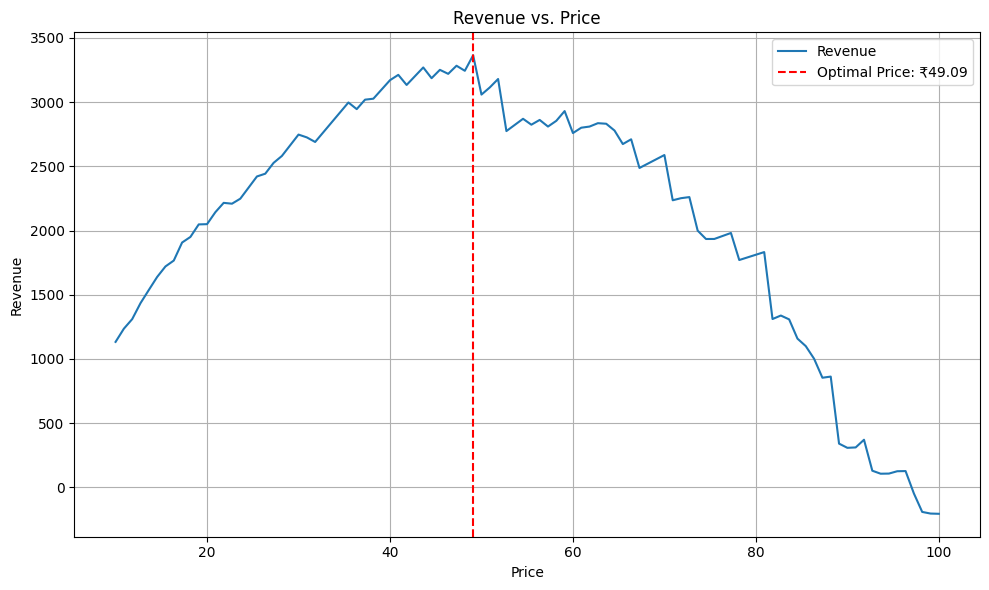

💰 Optimal Price: ₹49.09
📈 Max Predicted Revenue: ₹3365.39


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt

# === 1. Simulated Sample Dataset ===
np.random.seed(42)
n = 500

data = pd.DataFrame({
    'Price': np.random.uniform(10, 100, n),
    'Competitor_Price': np.random.uniform(10, 100, n),
    'DayOfWeek': np.random.choice(range(7), n),
    'Promo': np.random.choice([0, 1], n),
    'Seasonality': np.random.choice(['Winter', 'Summer', 'Spring', 'Fall'], n)
})

# Add sales with some realistic patterns
data['Units_Sold'] = (
    100 - data['Price'] * 0.8 +
    (data['Competitor_Price'] - data['Price']) * 0.5 +
    data['Promo'] * 10 +
    data['DayOfWeek'].apply(lambda x: 5 if x in [5, 6] else 0) +
    np.random.normal(0, 5, n)
).clip(lower=0)

# Encode categorical feature and store the column names
data = pd.get_dummies(data, columns=['Seasonality'], drop_first=True)
feature_names = data.drop('Units_Sold', axis=1).columns

# === 2. Train a Model to Predict Units Sold ===
X = data.drop(['Units_Sold'], axis=1)
y = data['Units_Sold']

model = GradientBoostingRegressor()
model.fit(X, y)

# === 3. Predict Revenue at Different Prices ===
def predict_revenue(price, competitor_price=50, promo=0, day=2, season='Summer'):
    input_data = pd.DataFrame([{
        'Price': price,
        'Competitor_Price': competitor_price,
        'Promo': promo,
        'DayOfWeek': day,
    }])
    # Add season columns with correct names and set the value for the specified season
    for col in feature_names:
        if col.startswith('Seasonality_'):
            season_name = col.split('_')[1]
            input_data[col] = int(season_name == season)

    # Ensure columns are in the same order as training data
    input_data = input_data[feature_names]

    predicted_units = model.predict(input_data)[0]
    revenue = price * predicted_units
    return revenue, predicted_units

# Generate revenue curve
prices = np.linspace(10, 100, 100)
revenues = [predict_revenue(p)[0] for p in prices]

# === 4. Plot Optimal Price Point ===
optimal_price = prices[np.argmax(revenues)]
max_revenue = max(revenues)

plt.figure(figsize=(10, 6))
plt.plot(prices, revenues, label="Revenue")
plt.axvline(optimal_price, color='red', linestyle='--', label=f'Optimal Price: ₹{optimal_price:.2f}')
plt.title("Revenue vs. Price")
plt.xlabel("Price")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"💰 Optimal Price: ₹{optimal_price:.2f}")
print(f"📈 Max Predicted Revenue: ₹{max_revenue:.2f}")